In [48]:
import tkinter as tk
from tkinter import filedialog, messagebox
import pandas as pd
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, root_mean_squared_error, r2_score
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import numpy as np
import seaborn as sns
from sklearn import preprocessing
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from ucimlrepo import fetch_ucirepo 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

xve = ''
yve = 'diagnosis_M'
fpv = 'datasets/Cancer_Data.csv'

#imports data
origData = pd.read_csv(fpv)
df = origData
#displays first 5 rows
print(df.head())

#checks for missing values
print(df.isnull().any())
#fills missing values
df = df.fillna(df.mode().iloc[0])
#print(df.head())

#scaling numerical columns
numerical_columns = df.select_dtypes(include=[np.number]).columns.tolist()
scaler = StandardScaler()
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

#oneHotEncoding and scaling
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded = encoder.fit_transform(df[categorical_columns])
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_columns))
df_encoded = pd.concat([df, one_hot_df], axis=1)
df_encoded = df_encoded.drop(categorical_columns, axis=1)

#dropping uneccesary columns
if(fpv=='datasets/Cancer_Data.csv'):
    df_encoded.drop('Unnamed: 32', axis=1, inplace=True)
    df_encoded.drop('id', axis=1, inplace=True)
print(df_encoded.head())

#getting columns in x
abc = df_encoded.columns.get_loc(yve)
test2 = []
test3 = []
for i in range(len(df_encoded.columns)):
    if(i != abc):
        test2.append(i)
for i in range(len(test2)):
    test3.append(df_encoded.columns[test2[i]])

#sets x and y
X = df_encoded[test3]
y = df_encoded[yve]

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

c:\Users\enson\OneDrive\Desktop\NewBeginnings\.venv\Lib\site-packages\sklearn\utils\extmath.py:1137: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
c:\Users\enson\OneDrive\Desktop\NewBeginnings\.venv\Lib\site-packages\sklearn\utils\extmath.py:1142: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
c:\Users\enson\OneDrive\Desktop\NewBeginnings\.venv\Lib\site-packages\sklearn\utils\extmath.py:1162: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [49]:
#80/20 train test split with random seed
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#commenting this out because scaling is already done beforehand
"""
#scales data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
"""

#first model
log_reg = LogisticRegression(max_iter=10000)
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
#printing scores/evaulation
print(f'Accuracy (Log Reg): {accuracy}')
print(f'F1 (Log Reg): {f1}')
print(f'Precision (Log Reg): {precision}')
print(f'Recall (Log Reg): {recall}')
print('Classification Report (Log Reg):')
print(classification_report(y_test, y_pred))

#second model
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
#printing scores/evaulation
print(f'Accuracy (Random Forest): {accuracy_rf}')
print(f'F1 (Random Forest): {f1_rf}')
print(f'Precision (Random Forest): {precision_rf}')
print(f'Recall (Random Forest): {recall_rf}')
print('Classification Report (Random Forest):')
print(classification_report(y_test, y_pred_rf))


Accuracy (Log Reg): 1.0
F1 (Log Reg): 1.0
Precision (Log Reg): 1.0
Recall (Log Reg): 1.0
Classification Report (Log Reg):
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        71
         1.0       1.00      1.00      1.00        43

    accuracy                           1.00       114
   macro avg       1.00      1.00      1.00       114
weighted avg       1.00      1.00      1.00       114

Accuracy (Random Forest): 1.0
F1 (Random Forest): 1.0
Precision (Random Forest): 1.0
Recall (Random Forest): 1.0
Classification Report (Random Forest):
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        71
         1.0       1.00      1.00      1.00        43

    accuracy                           1.00       114
   macro avg       1.00      1.00      1.00       114
weighted avg       1.00      1.00      1.00       114



In [50]:
#k fold cross validation
k_folds = KFold(n_splits = 5)
scores = cross_val_score(log_reg, X, y, cv = k_folds)
scoresRf = cross_val_score(rf_clf, X, y, cv = k_folds)

print("Cross Validation Scores: ", scores)
print("Average CV Score: ", scores.mean())

print("Cross Validation Scores (rf): ", scoresRf)
print("Average CV Score (rf): ", scoresRf.mean())

Cross Validation Scores:  [0.99122807 0.98245614 0.99122807 1.         1.        ]
Average CV Score:  0.9929824561403509
Cross Validation Scores (rf):  [1. 1. 1. 1. 1.]
Average CV Score (rf):  1.0


In [51]:
#t test
from mlxtend.evaluate import paired_ttest_5x2cv

t, p = paired_ttest_5x2cv(estimator1=log_reg,estimator2=rf_clf,X=X, y=y)
alpha = 0.05

print('t statistic: %.3f' % t)
print('aplha ', alpha)
print('p value: %.3f' % p)

if p > alpha:
  print("No signifigant difference between the 2 models")
else:
  print("Signifigant difference between the 2 models")

t statistic: -0.631
aplha  0.05
p value: 0.556
No signifigant difference between the 2 models


In [52]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

c:\Users\enson\OneDrive\Desktop\NewBeginnings\.venv\Lib\site-packages\keras\src\layers\core\dense.py:85: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 10)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 2)              │            22 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 342 (1.34 KB)

 Trainable params: 342 (1.34 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8355 - loss: 0.4455 - val_accuracy: 0.9737 - val_loss: 0.2184
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9256 - loss: 0.2131 - val_accuracy: 0.9737 - val_loss: 0.1231
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9462 - loss: 0.1483 - val_accuracy: 0.9912 - val_loss: 0.0858
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9737 - loss: 0.0962 - val_accuracy: 0.9912 - val_loss: 0.0668
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9720 - loss: 0.0743 - val_accuracy: 0.9912 - val_loss: 0.0565
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9939 - loss: 0.0604 - val_accuracy: 0.9912 - val_loss: 0.0492
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9843 - loss: 0.0736 - val_accuracy: 0.9912 - val_loss: 0.0432
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9941 - loss: 0.0403 - val_accuracy: 0.9912 - val_loss:

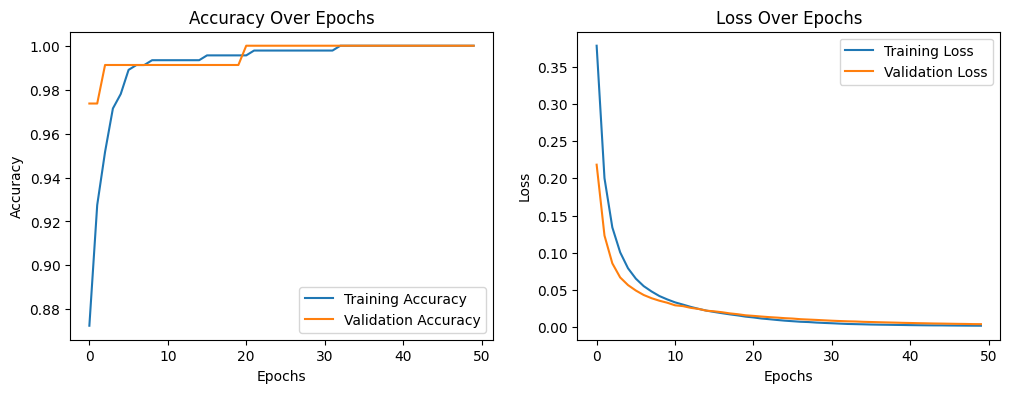

In [53]:
#neural network test

# Initialize the model
model = Sequential()

# Add input layer and hidden layer
model.add(Dense(10, input_shape=(X_train.shape[1],), activation='relu'))

# Add output layer
model.add(Dense(y_train.shape[1], activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print the model summary
model.summary()

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=5, validation_data=(X_test, y_test), verbose=1)

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {test_loss}')
print(f'Test Accuracy: {test_accuracy}')

# Plot training history
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Over Epochs')

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Over Epochs')

plt.show()